In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/gshs2015_for_clustering.csv")
df

,usia_norm,kelas_norm,bmi_norm,kesepian_norm,khawatir_insomnia_norm,diserang_fisik_norm,perkelahian_fisik_norm,hari_dibully_norm,hari_merokok_norm,hari_minum_alkohol_norm,...,gender_bin,jenjang_bin,bmi_encoded,flag_perokok_bin,flag_alkohol_bin,flag_narkoba_bin,flag_dibully_bin,flag_diserang_bin,flag_aktif_fisik_bin,target
0,0.000000,0.0,0.098203,0.0,0.00,0.000000,0.000000,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,0.285714,0.0,0.212098,0.0,0.00,0.000000,0.000000,0.0,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
2,0.142857,0.0,0.187074,0.0,0.00,0.285714,0.000000,0.0,0.0,0.0,...,1,0,1,0,0,0,0,1,0,0
3,0.285714,0.0,0.385073,0.5,0.50,0.285714,0.000000,0.0,0.0,0.0,...,1,0,2,0,0,0,0,1,1,0
4,0.142857,0.0,0.249542,0.0,0.00,0.285714,0.000000,0.0,0.0,0.0,...,1,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10972,0.285714,0.2,0.396742,0.5,0.25,0.428571,0.285714,0.0,0.0,0.0,...,1,0,2,0,0,0,0,1,0,0
10973,0.428571,0.4,0.163594,1.0,0.00,0.000000,0.000000,0.0,0.0,0.0,...,1,1,1,0,0,0,0,0,0,1
10974,0.428571,0.4,0.091453,0.0,0.25,0.000000,0.000000,0.0,0.0,0.0,...,1,1,0,0,0,0,0,0,0,0
10975,0.285714,0.4,0.143131,0.5,1.00,0.000000,0.000000,0.0,0.0,0.0,...,1,0,0,0,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10977 entries, 0 to 10976
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   usia_norm                 10977 non-null  float64
 1   kelas_norm                10977 non-null  float64
 2   bmi_norm                  10977 non-null  float64
 3   kesepian_norm             10977 non-null  float64
 4   khawatir_insomnia_norm    10977 non-null  float64
 5   diserang_fisik_norm       10977 non-null  float64
 6   perkelahian_fisik_norm    10977 non-null  float64
 7   hari_dibully_norm         10977 non-null  float64
 8   hari_merokok_norm         10977 non-null  float64
 9   hari_minum_alkohol_norm   10977 non-null  float64
 10  frek_mabuk_norm           10977 non-null  float64
 11  mh_risk_score_norm        10977 non-null  float64
 12  behavior_risk_score_norm  10977 non-null  float64
 13  gender_bin                10977 non-null  int64  
 14  jenjan

In [4]:
df = df.drop(df.columns[[1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 21]], axis=1)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10977 entries, 0 to 10976
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   usia_norm               10977 non-null  float64
 1   kesepian_norm           10977 non-null  float64
 2   khawatir_insomnia_norm  10977 non-null  float64
 3   gender_bin              10977 non-null  int64  
 4   flag_perokok_bin        10977 non-null  int64  
 5   flag_alkohol_bin        10977 non-null  int64  
 6   flag_narkoba_bin        10977 non-null  int64  
 7   flag_dibully_bin        10977 non-null  int64  
 8   flag_diserang_bin       10977 non-null  int64  
 9   target                  10977 non-null  int64  
dtypes: float64(3), int64(7)
memory usage: 857.7 KB


K MEANS

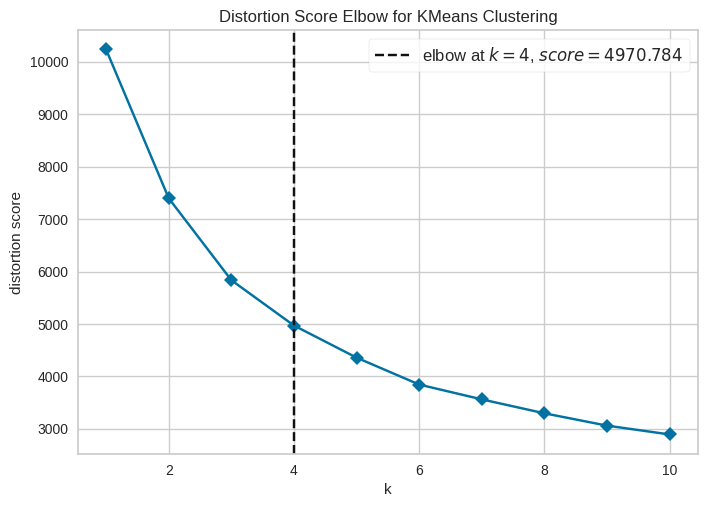

KElbowVisualizer(ax=<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>,
                 estimator=KMeans(n_clusters=10, n_init=25, random_state=123),
                 k=(1, 11), timings=False)

In [6]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import kelbow_visualizer

model = KMeans(n_init=25, random_state=123)

kelbow_visualizer(model, df, k=(1, 11), timings=False)

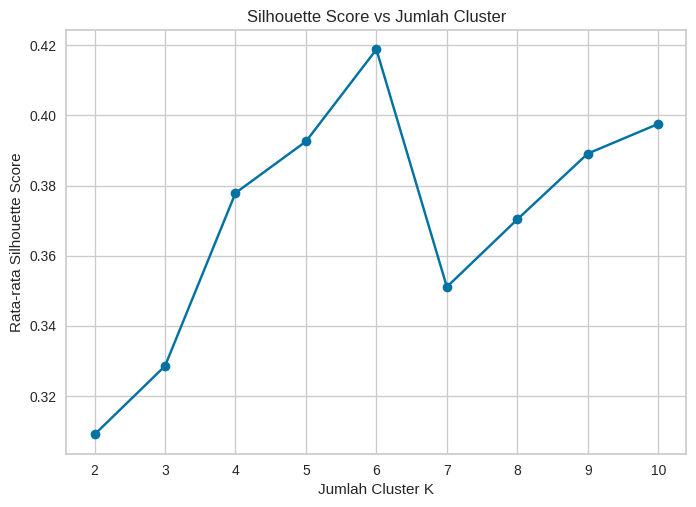

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init=25, random_state=123)
    labels = kmeans.fit_predict(df)

    score = silhouette_score(df, labels, metric='euclidean')
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Jumlah Cluster K')
plt.ylabel('Rata-rata Silhouette Score')
plt.title('Silhouette Score vs Jumlah Cluster')
plt.show()

In [8]:
kmeans_final = KMeans(n_clusters=4, n_init=25, random_state=123)
labels_final = kmeans_final.fit_predict(df)

In [9]:
X = np.array(df)  # as array
overall_mean = np.mean(X, axis=0)
totss = np.sum((X - overall_mean) ** 2)

tot_withinss = kmeans_final.inertia_

betweenss = totss - tot_withinss

explained_variation = betweenss / totss

print(f"Total SS (totss): {totss:.2f}")
print(f"Total Within SS (tot.withinss): {tot_withinss:.2f}")
print(f"Between SS (betweenss): {betweenss:.2f}")
print(f"Persentase variasi dijelaskan: {explained_variation:.2%}")

Total SS (totss): 10235.32
Total Within SS (tot.withinss): 4970.78
Between SS (betweenss): 5264.53
Persentase variasi dijelaskan: 51.43%


HAG

In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist

distance_matrix = pdist(df, metric='euclidean')

In [11]:
Z_complete = linkage(distance_matrix, method='complete')
Z_average = linkage(distance_matrix, method='average')
Z_single = linkage(distance_matrix, method='single')

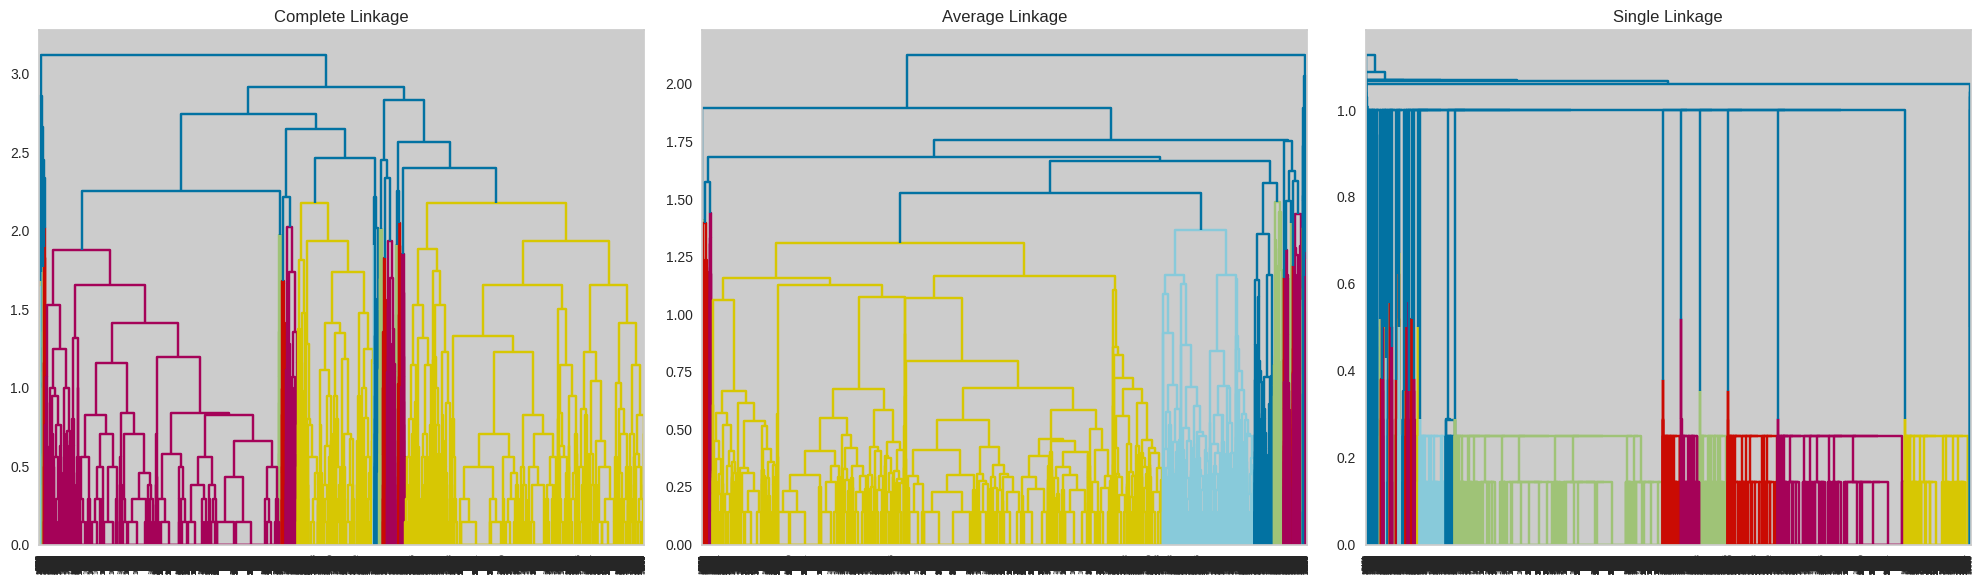

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

dendrogram(Z_complete, ax=axes[0])
axes[0].set_title("Complete Linkage")

dendrogram(Z_average, ax=axes[1])
axes[1].set_title("Average Linkage")

dendrogram(Z_single, ax=axes[2])
axes[2].set_title("Single Linkage")

plt.tight_layout()
plt.show()

In [13]:
from scipy.cluster.hierarchy import cophenet

# Complete
c_complete, coph_dist_complete = cophenet(Z_complete, distance_matrix)
print("Cophenetic correlation (Complete):", c_complete)

# Average
c_average, coph_dist_average = cophenet(Z_average, distance_matrix)
print("Cophenetic correlation (Average):", c_average)

# Single
c_single, coph_dist_single = cophenet(Z_single, distance_matrix)
print("Cophenetic correlation (Single):", c_single)

Cophenetic correlation (Complete): 0.7809166698233933
Cophenetic correlation (Average): 0.8699449059088032
Cophenetic correlation (Single): 0.7674661173165669


In [14]:
from sklearn.cluster import AgglomerativeClustering

hag_model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='average')

# fit model ke data_scaled dan langsung simpan hasilnya ke variabel labels_hag
labels_hag = hag_model.fit_predict(df)

In [15]:
# copy df dulu supaya df asli nya ga kenapa-napa
df_copy = df.copy()

# masukkan hasil cluster ke DataFrame asli
df_copy['cluster_hag'] = labels_hag

# lihat karakteristik rata-rata tiap cluster
cluster_profile = df_copy.groupby('cluster_hag').mean()

# tampilkan profil cluster
cluster_profile

,usia_norm,kesepian_norm,khawatir_insomnia_norm,gender_bin,flag_perokok_bin,flag_alkohol_bin,flag_narkoba_bin,flag_dibully_bin,flag_diserang_bin,target
cluster_hag,,,,,,,,,,
0,0.243243,0.182432,0.189189,0.243243,0.702703,0.405405,1.000000,0.189189,0.648649,0.513514
1,0.435049,0.277650,0.251629,0.548233,0.023772,0.033685,0.004406,0.186324,0.314915,0.050023
2,0.266667,0.433333,0.516667,1.000000,1.000000,0.600000,0.733333,0.933333,0.866667,0.666667
3,0.438095,0.450000,0.291667,0.233333,0.500000,1.000000,0.000000,0.433333,0.866667,1.000000


In [16]:
df_copy['cluster_hag'].value_counts()

,count
cluster_hag,
1,10895
0,37
3,30
2,15


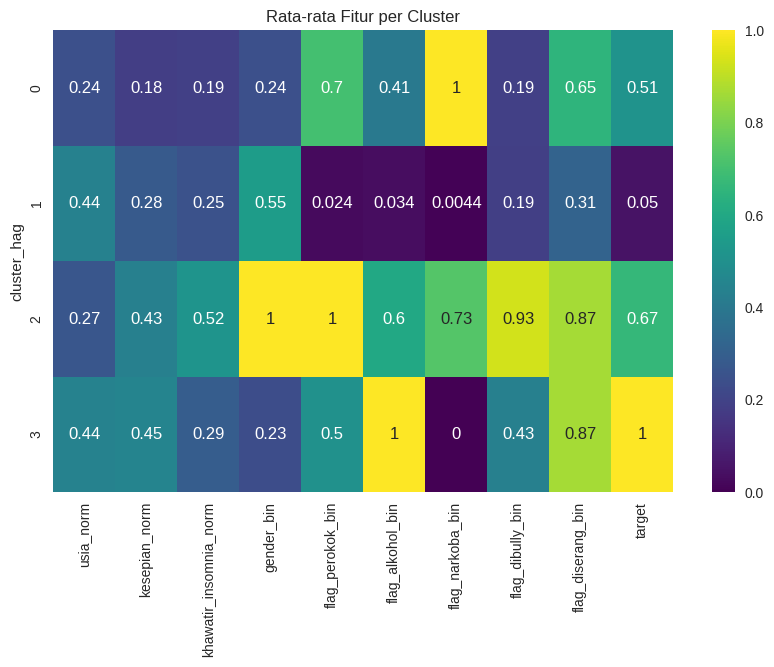

In [17]:
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile, annot=True, cmap='viridis')
plt.title('Rata-rata Fitur per Cluster')
plt.show()

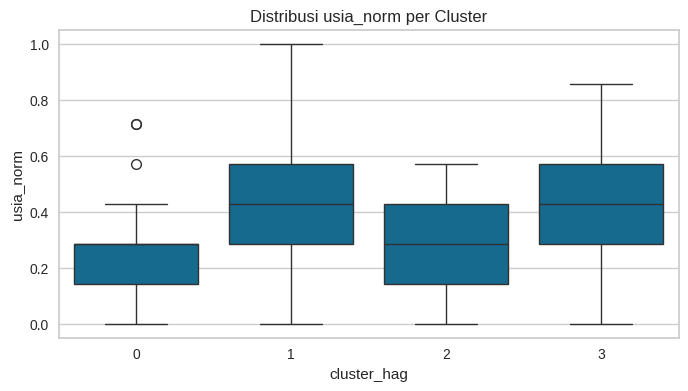

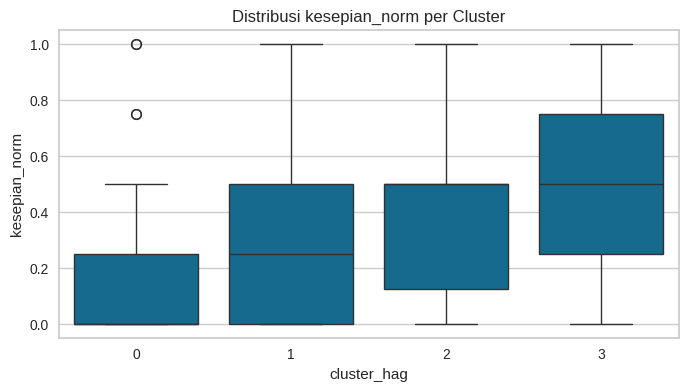

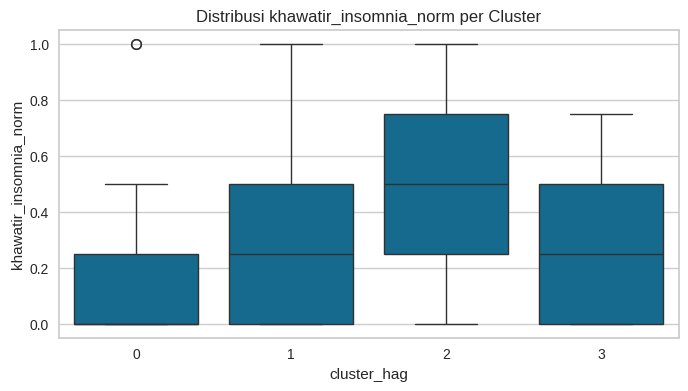

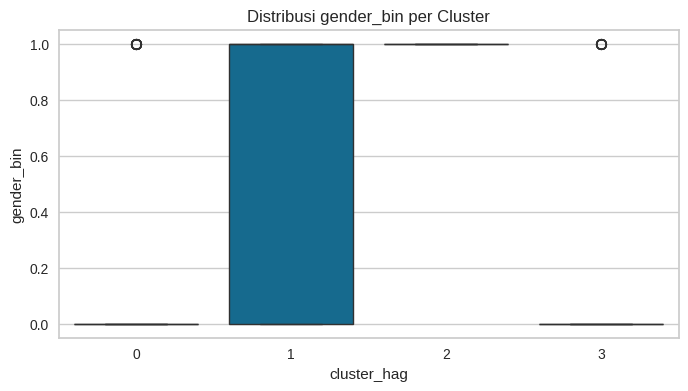

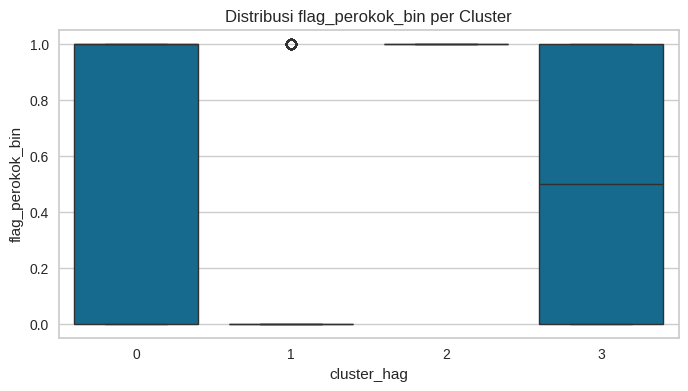

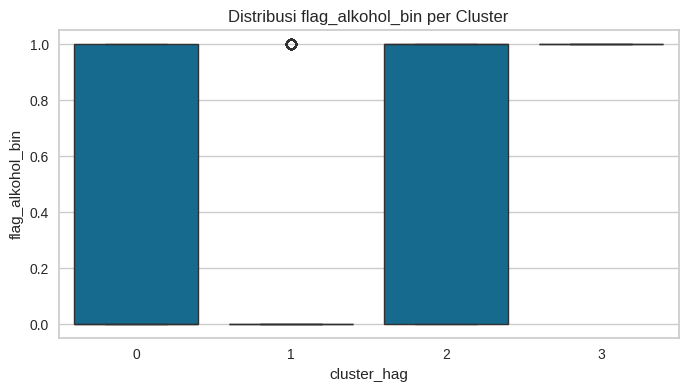

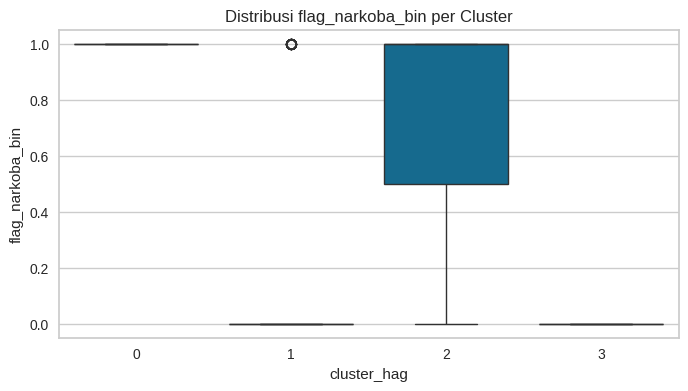

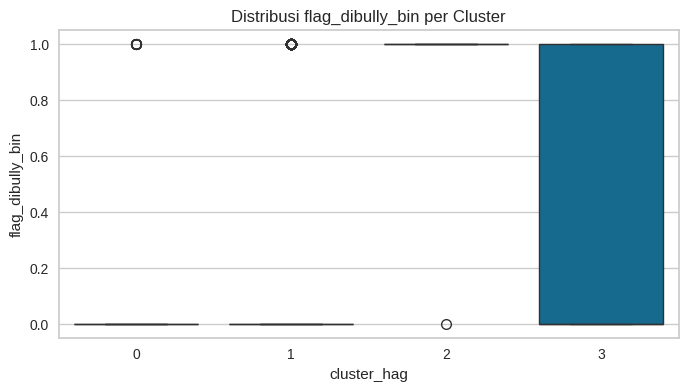

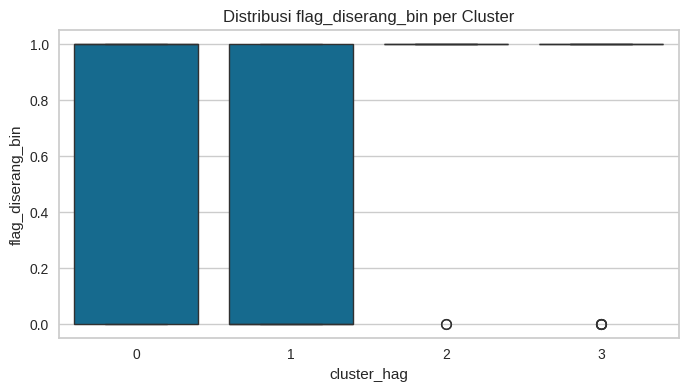

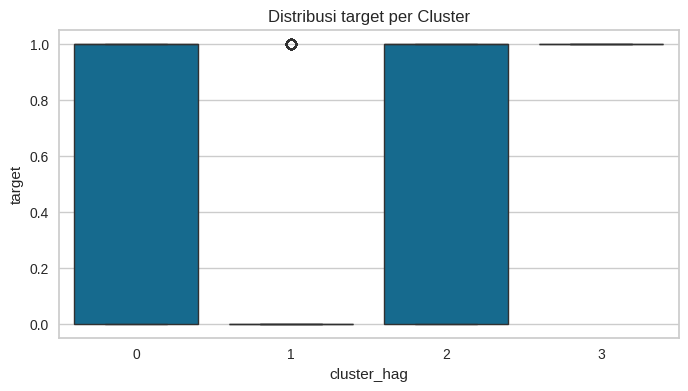

In [18]:
for col in df_copy.columns[:-1]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_copy, x='cluster_hag', y=col)
    plt.title(f'Distribusi {col} per Cluster')
    plt.show()

HAG: WARD

In [19]:
# Ward Linkage
Z_ward = linkage(distance_matrix, method='ward')

c_ward, coph_dist_ward = cophenet(Z_ward, distance_matrix)
print("Cophenetic correlation (Ward):", c_ward)

Cophenetic correlation (Ward): 0.6639559836476819


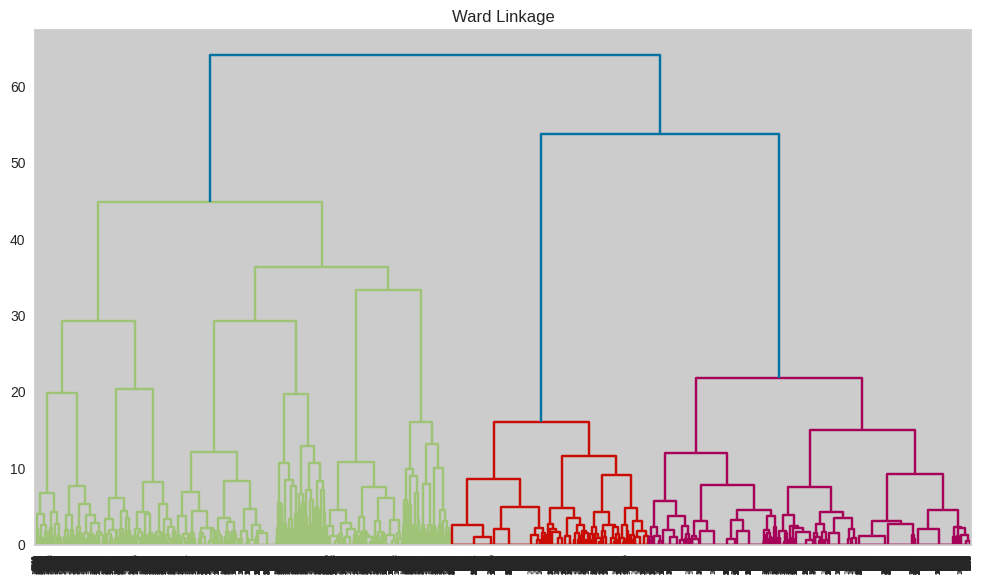

In [20]:
plt.figure(figsize=(10, 6))
dendrogram(Z_ward)
plt.title("Ward Linkage")
plt.tight_layout()
plt.show()

In [21]:
hag_ward = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
labels_ward = hag_ward.fit_predict(df)

In [22]:
df_ward = df.copy()
df_ward['cluster_ward'] = labels_ward

cluster_profile_ward = df_ward.groupby('cluster_ward').mean()
cluster_profile_ward

,usia_norm,kesepian_norm,khawatir_insomnia_norm,gender_bin,flag_perokok_bin,flag_alkohol_bin,flag_narkoba_bin,flag_dibully_bin,flag_diserang_bin,target
cluster_ward,,,,,,,,,,
0,0.430647,0.317002,0.293199,0.439567,0.097372,0.130139,0.029675,0.127048,0.817002,0.186708
1,0.416213,0.346945,0.316697,0.489413,0.000000,0.000000,0.000000,1.000000,0.514822,0.000000
2,0.440415,0.190630,0.172604,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.441256,0.268023,0.236748,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [23]:
df_ward['cluster_ward'].value_counts()

,count
cluster_ward,
3,3773
0,3235
2,2316
1,1653


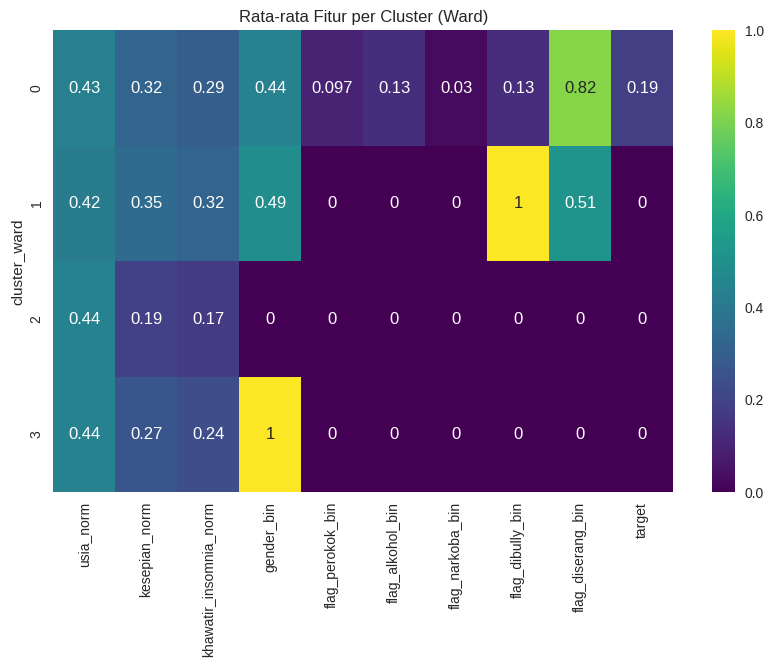

In [24]:
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile_ward, annot=True, cmap='viridis')
plt.title('Rata-rata Fitur per Cluster (Ward)')
plt.show()

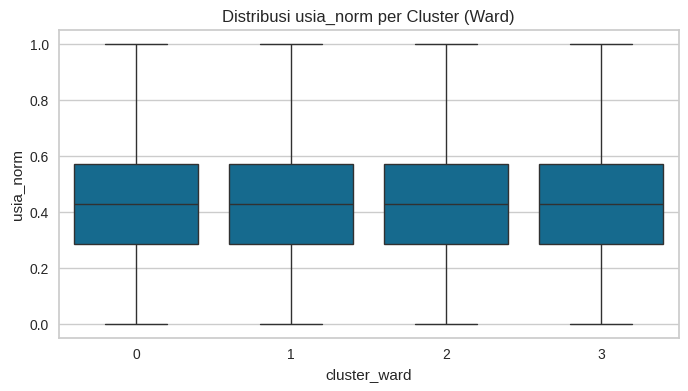

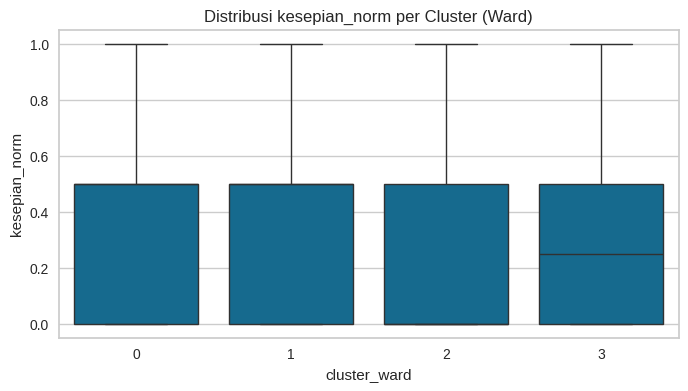

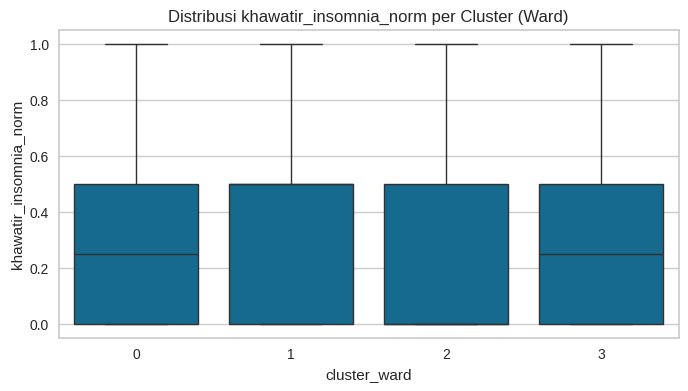

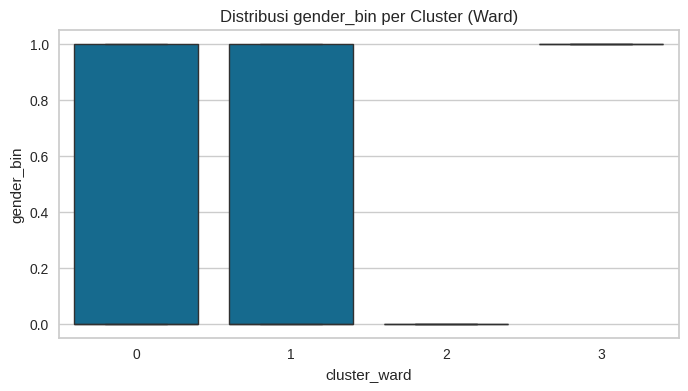

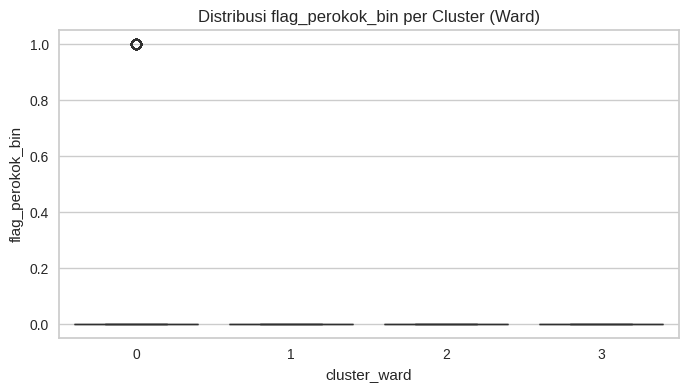

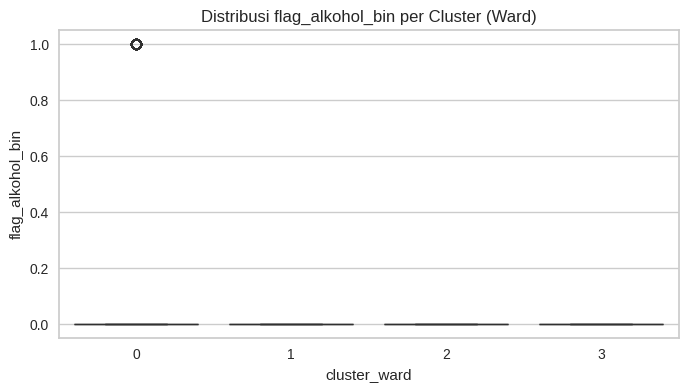

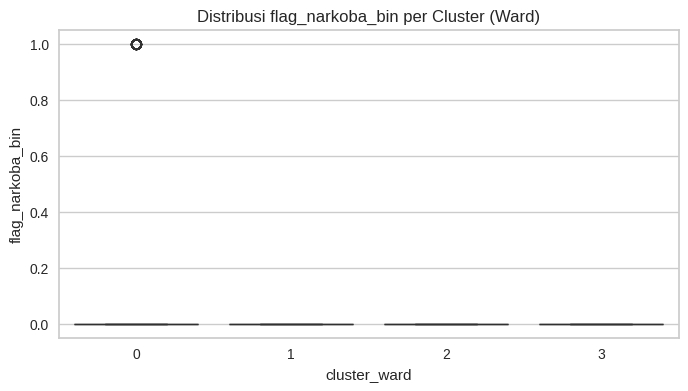

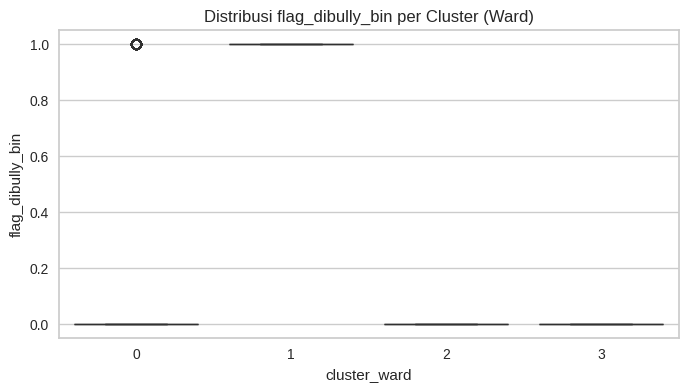

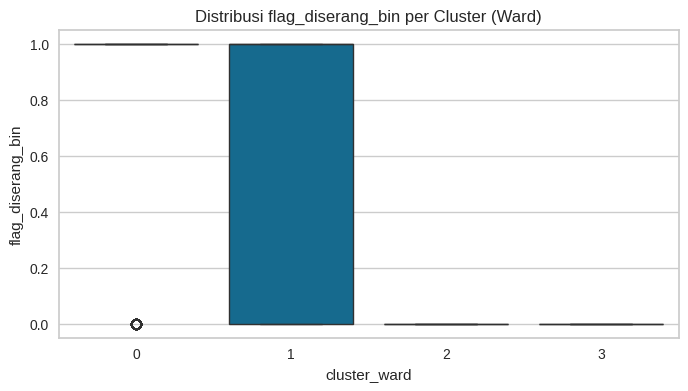

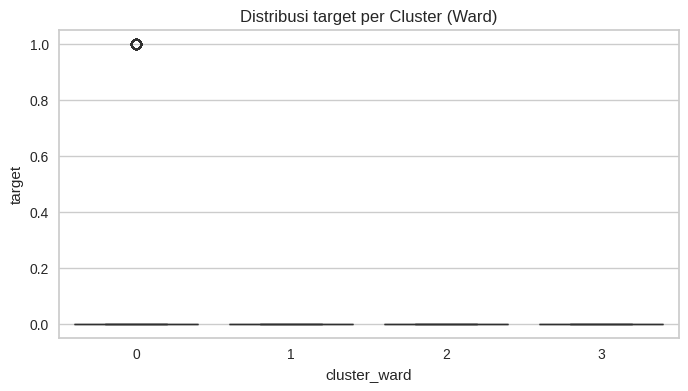

In [25]:
for col in df_ward.columns[:-1]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_ward, x='cluster_ward', y=col)
    plt.title(f'Distribusi {col} per Cluster (Ward)')
    plt.show()

PERBANDINGAN HASIL SEMUANYA

In [46]:
from sklearn.metrics import silhouette_score

sil_kmeans  = silhouette_score(df, labels_final,  metric='euclidean')
sil_ward    = silhouette_score(df, labels_ward,   metric='euclidean')
sil_average = silhouette_score(df, labels_hag,    metric='euclidean')

print(f"Silhouette Score KMeans      : {sil_kmeans:.4f}")
print(f"Silhouette Score HAG Ward    : {sil_ward:.4f}")
print(f"Silhouette Score HAG Average : {sil_average:.4f}")

Silhouette Score KMeans      : 0.3779
Silhouette Score HAG Ward    : 0.3073
Silhouette Score HAG Average : 0.3648


In [47]:
X = np.array(df)
overall_mean = np.mean(X, axis=0)
totss = np.sum((X - overall_mean) ** 2)

# within ss ward
withinss_ward = sum(
    np.sum((X[labels_ward == c] - np.mean(X[labels_ward == c], axis=0)) ** 2)
    for c in np.unique(labels_ward)
)
explained_ward = (totss - withinss_ward) / totss

# within ss average
withinss_average = sum(
    np.sum((X[labels_hag == c] - np.mean(X[labels_hag == c], axis=0)) ** 2)
    for c in np.unique(labels_hag)
)
explained_average = (totss - withinss_average) / totss

comparison = pd.DataFrame({
    'Algoritma'          : ['KMeans', 'HAG Ward', 'HAG Average'],
    'Silhouette Score'   : [round(sil_kmeans, 4), round(sil_ward, 4), round(sil_average, 4)],
    'Explained Variation': [f"{explained_variation:.2%}", f"{explained_ward:.2%}", f"{explained_average:.2%}"],
    'Jumlah Cluster'     : [4, 4, 4],
})

comparison

,Algoritma,Silhouette Score,Explained Variation,Jumlah Cluster
0,KMeans,0.3779,51.43%,4
1,HAG Ward,0.3073,44.10%,4
2,HAG Average,0.3648,1.98%,4


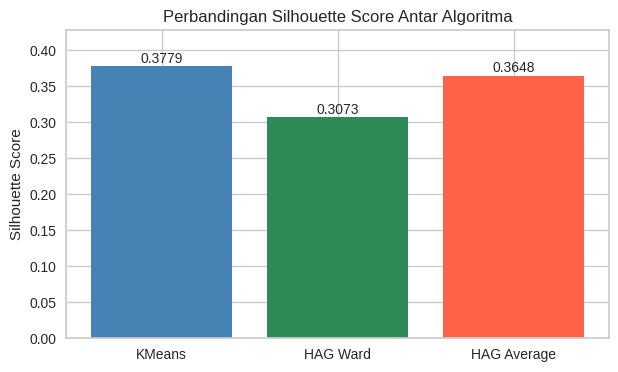

In [48]:
plt.figure(figsize=(7, 4))
plt.bar(['KMeans', 'HAG Ward', 'HAG Average'],
        [sil_kmeans, sil_ward, sil_average],
        color=['steelblue', 'seagreen', 'tomato'])
plt.ylabel('Silhouette Score')
plt.title('Perbandingan Silhouette Score Antar Algoritma')
plt.ylim(0, max(sil_kmeans, sil_ward, sil_average) + 0.05)
for i, v in enumerate([sil_kmeans, sil_ward, sil_average]):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontsize=10)
plt.show()

VISUALISASI HASIL CLUSTER TERBAIK

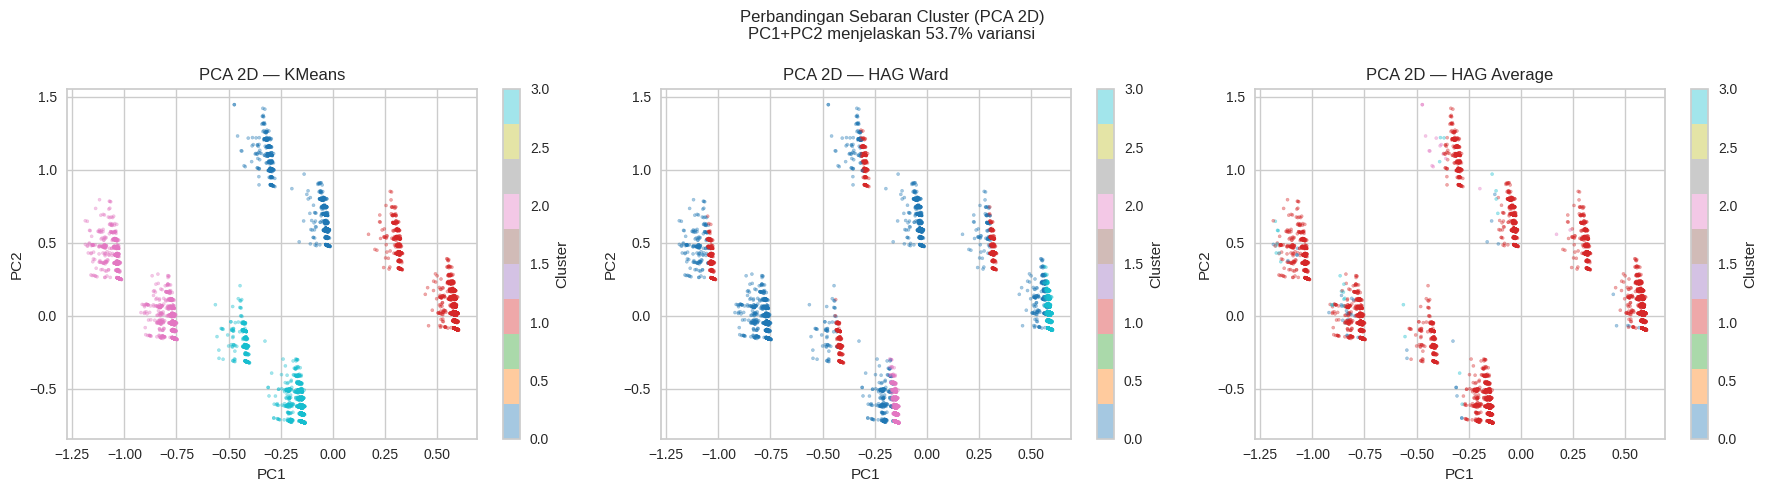

In [49]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=123)
X_pca = pca.fit_transform(df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, labels) in zip(axes, [
    ('KMeans',      labels_final),
    ('HAG Ward',    labels_ward),
    ('HAG Average', labels_hag),
]):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                         c=labels, cmap='tab10', alpha=0.4, s=5)
    ax.set_title(f'PCA 2D — {title}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.suptitle(f'Perbandingan Sebaran Cluster (PCA 2D)\n'
             f'PC1+PC2 menjelaskan {sum(pca.explained_variance_ratio_)*100:.1f}% variansi',
             fontsize=12)
plt.tight_layout()
plt.show()

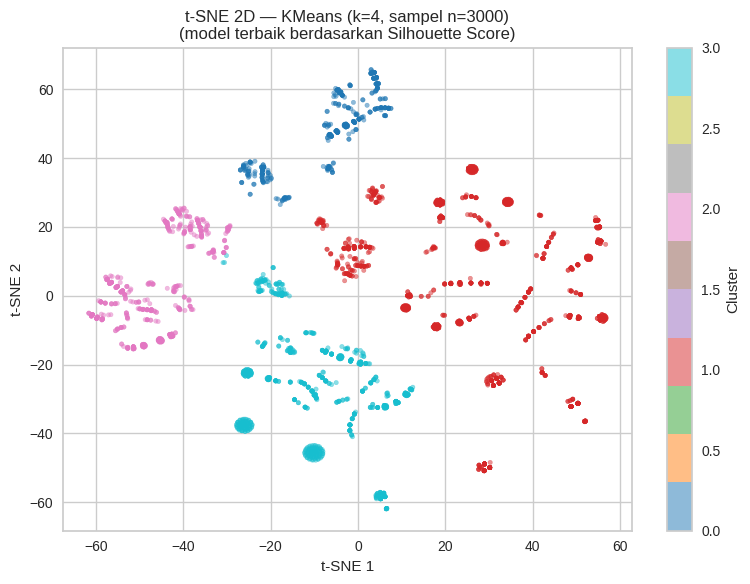

In [50]:
# ganti 'labels_best' dan judulnya sesuai model dengan silhouette score tertinggi
from sklearn.manifold import TSNE

best_algo   = comparison.loc[comparison['Silhouette Score'].idxmax(), 'Algoritma']
best_labels = {'KMeans': labels_final, 'HAG Ward': labels_ward, 'HAG Average': labels_hag}[best_algo]

np.random.seed(123)
idx_tsne = np.random.choice(len(df), size=3000, replace=False)
X_tsne = TSNE(n_components=2, perplexity=40, random_state=123).fit_transform(df.values[idx_tsne])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=best_labels[idx_tsne], cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title(f't-SNE 2D — {best_algo} (k=4, sampel n=3000)\n(model terbaik berdasarkan Silhouette Score)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

In [51]:
df_best = df.copy()
df_best['cluster'] = best_labels

cluster_profile_best = df_best.groupby('cluster').mean().round(3)
cluster_profile_best

,usia_norm,kesepian_norm,khawatir_insomnia_norm,gender_bin,flag_perokok_bin,flag_alkohol_bin,flag_narkoba_bin,flag_dibully_bin,flag_diserang_bin,target
cluster,,,,,,,,,,
0,0.397,0.374,0.327,1.0,0.024,0.026,0.010,0.305,1.0,0.109
1,0.445,0.289,0.256,1.0,0.010,0.013,0.002,0.122,0.0,0.051
2,0.411,0.282,0.274,0.0,0.073,0.088,0.022,0.330,1.0,0.063
3,0.452,0.210,0.193,0.0,0.030,0.049,0.009,0.134,0.0,0.029


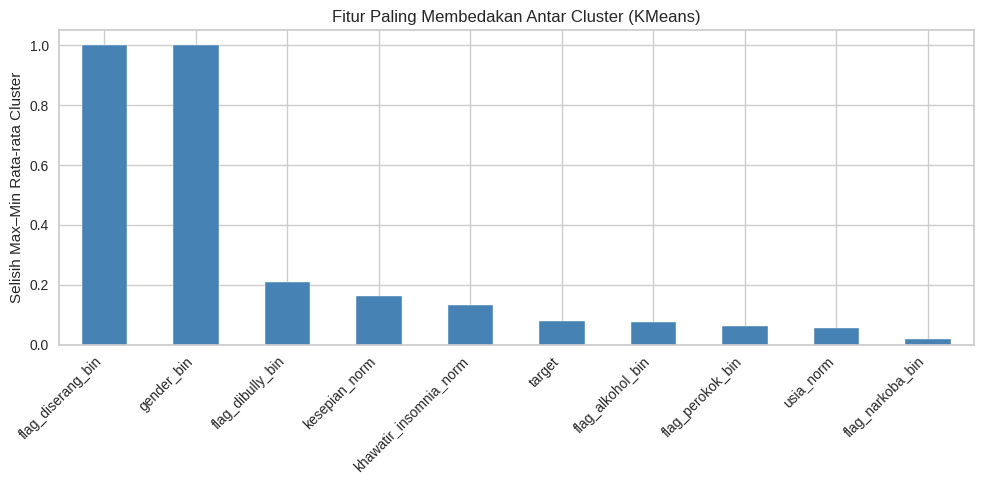

In [52]:
range_per_fitur = cluster_profile_best.max() - cluster_profile_best.min()
range_per_fitur = range_per_fitur.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
range_per_fitur.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title(f'Fitur Paling Membedakan Antar Cluster ({best_algo})')
plt.ylabel('Selisih Max–Min Rata-rata Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

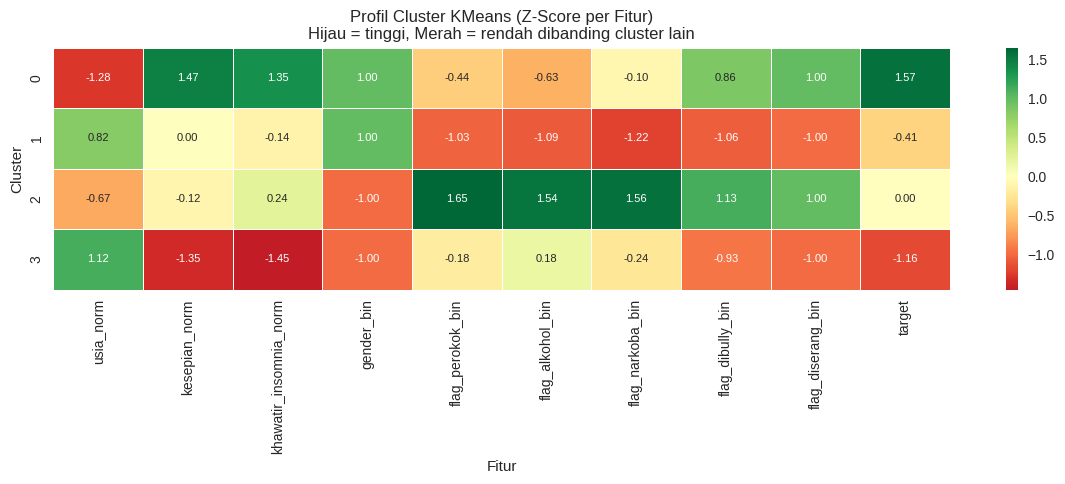

In [53]:
from scipy.stats import zscore

profile_z = cluster_profile_best.apply(zscore, axis=0)

plt.figure(figsize=(12, 5))
sns.heatmap(profile_z, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title(f'Profil Cluster {best_algo} (Z-Score per Fitur)\n'
          'Hijau = tinggi, Merah = rendah dibanding cluster lain')
plt.xlabel('Fitur')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [54]:
print("=" * 55)
print(f"PROFIL TIAP CLUSTER ({best_algo})")
print("=" * 55)

ukuran = df_best['cluster'].value_counts().sort_index()

for c in sorted(df_best['cluster'].unique()):
    n   = ukuran[c]
    pct = n / len(df_best) * 100
    top3    = cluster_profile_best.loc[c].nlargest(3)
    bottom3 = cluster_profile_best.loc[c].nsmallest(3)

    print(f"\nCluster {c}  →  {n:,} pelajar ({pct:.1f}%)")
    print(f"  Fitur TERTINGGI  : {', '.join([f'{f} ({v:.2f})' for f, v in top3.items()])}")
    print(f"  Fitur TERENDAH   : {', '.join([f'{f} ({v:.2f})' for f, v in bottom3.items()])}")

print("\n" + "=" * 55)

PROFIL TIAP CLUSTER (KMeans)

Cluster 0  →  1,445 pelajar (13.2%)
  Fitur TERTINGGI  : gender_bin (1.00), flag_diserang_bin (1.00), usia_norm (0.40)
  Fitur TERENDAH   : flag_narkoba_bin (0.01), flag_perokok_bin (0.02), flag_alkohol_bin (0.03)

Cluster 1  →  4,559 pelajar (41.5%)
  Fitur TERTINGGI  : gender_bin (1.00), usia_norm (0.45), kesepian_norm (0.29)
  Fitur TERENDAH   : flag_diserang_bin (0.00), flag_narkoba_bin (0.00), flag_perokok_bin (0.01)

Cluster 2  →  2,049 pelajar (18.7%)
  Fitur TERTINGGI  : flag_diserang_bin (1.00), usia_norm (0.41), flag_dibully_bin (0.33)
  Fitur TERENDAH   : gender_bin (0.00), flag_narkoba_bin (0.02), target (0.06)

Cluster 3  →  2,924 pelajar (26.6%)
  Fitur TERTINGGI  : usia_norm (0.45), kesepian_norm (0.21), khawatir_insomnia_norm (0.19)
  Fitur TERENDAH   : gender_bin (0.00), flag_diserang_bin (0.00), flag_narkoba_bin (0.01)



DETEKSI OUTLIER DBSCAN

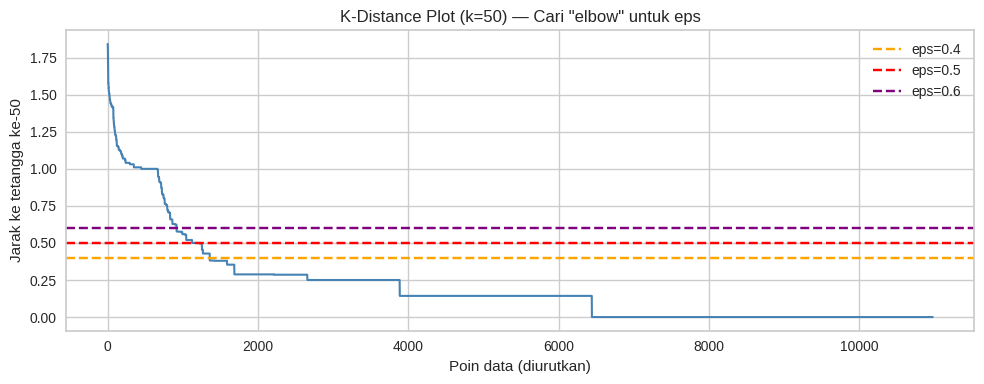

In [55]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=50).fit(df)
distances, _ = nbrs.kneighbors(df)
k_dist = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_dist, color='steelblue', lw=1.5)
plt.axhline(0.4, color='orange', ls='--', label='eps=0.4')
plt.axhline(0.5, color='red',    ls='--', label='eps=0.5')
plt.axhline(0.6, color='purple', ls='--', label='eps=0.6')
plt.title('K-Distance Plot (k=50) — Cari "elbow" untuk eps')
plt.xlabel('Poin data (diurutkan)')
plt.ylabel('Jarak ke tetangga ke-50')
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
from sklearn.cluster import DBSCAN

configs = [
    {'eps': 0.4, 'min_samples': 50},
    {'eps': 0.5, 'min_samples': 50},
    {'eps': 0.5, 'min_samples': 30},
    {'eps': 0.6, 'min_samples': 50},
]

print(f"{'eps':>6}  {'min_s':>6}  {'Noise':>7}  {'Noise%':>7}")
print('-' * 35)
for cfg in configs:
    db  = DBSCAN(eps=cfg['eps'], min_samples=cfg['min_samples'])
    lbl = db.fit_predict(df)
    nn  = (lbl == -1).sum()
    print(f"{cfg['eps']:>6}  {cfg['min_samples']:>6}  {nn:>7}  {nn/len(df)*100:>6.1f}%")

   eps   min_s    Noise   Noise%
-----------------------------------
   0.4      50     1006     9.2%
   0.5      50      865     7.9%
   0.5      30      610     5.6%
   0.6      50      723     6.6%


In [57]:
# sesuaikan eps dan min_samples berdasarkan hasil tabel di atas
dbscan = DBSCAN(eps=0.5, min_samples=50)
labels_db = dbscan.fit_predict(df)

n_noise = (labels_db == -1).sum()
print(f"Jumlah outlier (noise) : {n_noise} ({n_noise/len(df)*100:.1f}%)")
print(f"Jumlah poin normal     : {(labels_db != -1).sum()}")

Jumlah outlier (noise) : 865 (7.9%)
Jumlah poin normal     : 10112


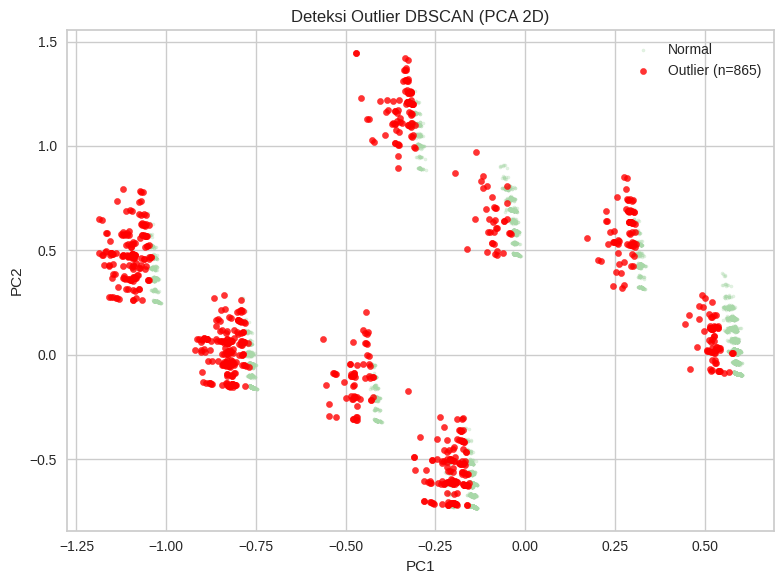

In [58]:
noise_mask = labels_db == -1

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[~noise_mask, 0], X_pca[~noise_mask, 1],
            c='#A8D8A8', alpha=0.3, s=5, label='Normal')
plt.scatter(X_pca[noise_mask, 0],  X_pca[noise_mask, 1],
            c='red', alpha=0.8, s=20, label=f'Outlier (n={n_noise})')
plt.title('Deteksi Outlier DBSCAN (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

In [60]:
df_outlier = df.copy()
df_outlier['cluster']    = best_labels
df_outlier['is_outlier'] = noise_mask.astype(int)

outlier_per_cluster = df_outlier.groupby('cluster')['is_outlier'].agg(['sum', 'mean'])
outlier_per_cluster.columns = ['jumlah_outlier', 'rasio_outlier']
outlier_per_cluster['rasio_outlier'] = outlier_per_cluster['rasio_outlier'].map('{:.2%}'.format)
print(f"Distribusi outlier per cluster {best_algo}:")
print(outlier_per_cluster)

Distribusi outlier per cluster KMeans:
         jumlah_outlier rasio_outlier
cluster                              
0                   140         9.69%
1                   158         3.47%
2                   358        17.47%
3                   209         7.15%


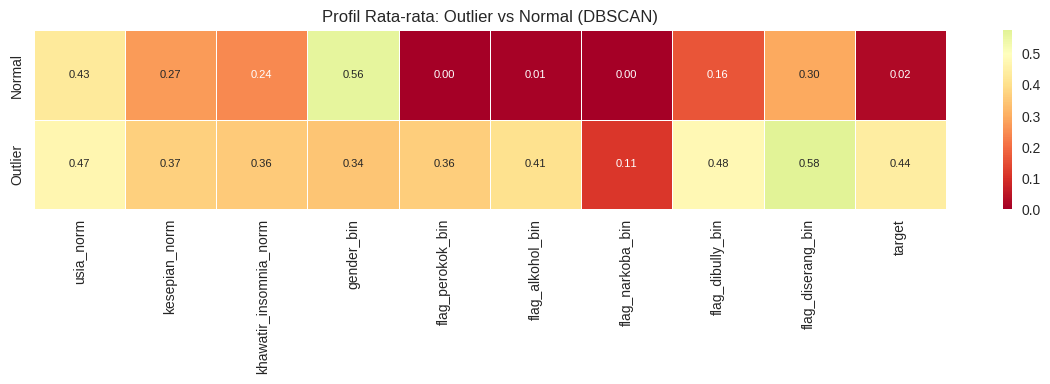

In [61]:
df_outlier_profil = df.copy()
df_outlier_profil['is_outlier'] = noise_mask

profil_outlier = df_outlier_profil.groupby('is_outlier').mean().round(3)
profil_outlier.index = ['Normal', 'Outlier']

plt.figure(figsize=(12, 4))
sns.heatmap(profil_outlier, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0.5, linewidths=0.4, annot_kws={'size': 8})
plt.title('Profil Rata-rata: Outlier vs Normal (DBSCAN)')
plt.tight_layout()
plt.show()